In [ ]:
# Load Basic Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load make_blobs Dataset from sklearn library
from sklearn.datasets import make_blobs

# Load LogisticRegression from sklearn library
from sklearn.linear_model import LogisticRegression

# Load train_test_split from sklearn library
from sklearn.model_selection import train_test_split

In [ ]:
x,y = make_blobs(n_samples=1000,n_features=2,centers=1,random_state=23,cluster_std=2.0)
x

array([[ 0.52614556,  8.75136291],
       [-2.15104954,  8.23286685],
       [-2.14365846,  8.00003618],
       ...,
       [ 0.22794962,  9.12036227],
       [ 2.75809847,  7.35617704],
       [ 0.7751279 , 11.14105029]])

In [ ]:
x.size

2000

In [ ]:
x.shape

(1000, 2)

In [ ]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
y.size

1000

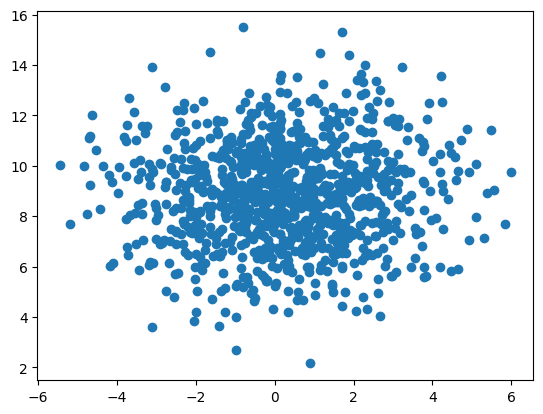

In [ ]:
plt.scatter(x[:,0],x[:,1])

Split Data In Train and Test Variables

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=43)
x_train[1].max()

np.float64(12.554480518657094)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [ ]:
# Model BUilding
from sklearn.cluster import KMeans

In [ ]:
# Best VAlue for K by using Elbow Method
k_range = range(1,15)
wcss = []
for k in k_range:
  kmean= KMeans(n_clusters=k,init = "k-means++")
  kmean.fit(x_train)
  wcss.append(kmean.inertia_)

In [ ]:
wcss

[1399.9999999999993,
 964.4285449619848,
 643.2450301868914,
 499.07906578054906,
 436.1429611155728,
 350.2043483094678,
 303.51753245868497,
 270.2565302975229,
 247.9932915325145,
 227.78323643170765,
 201.10641050137798,
 185.83776118649882,
 170.0918843011472,
 165.41096059265058]

Text(0, 0.5, 'WCSS')

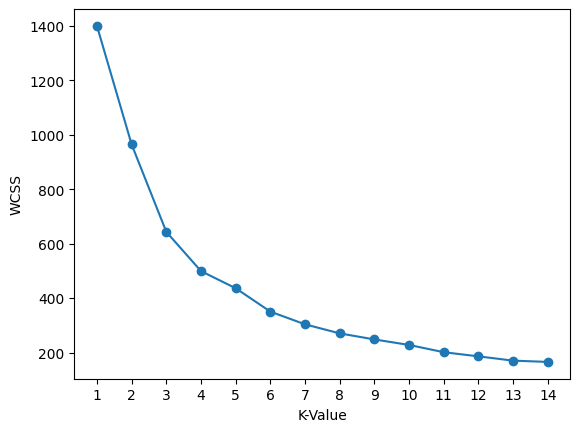

In [ ]:
# ELbow-graph
plt.plot(k_range,wcss,marker ="o")
plt.xticks(k_range)
plt.xlabel("K-Value")
plt.ylabel("WCSS")

In [ ]:
# For K = 3
kmean = KMeans(n_clusters=3,init = "k-means++")
kmean.fit_transform(x_train)
y_label = kmean.labels_
y_label

array([0, 1, 0, 1, 0, 1, 2, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 2, 2, 0, 0, 1,
       0, 2, 0, 1, 2, 0, 1, 0, 0, 2, 1, 0, 2, 0, 1, 0, 2, 1, 0, 2, 2, 0,
       0, 1, 0, 1, 2, 1, 0, 2, 1, 0, 0, 1, 1, 2, 2, 1, 2, 0, 0, 2, 2, 2,
       2, 1, 1, 2, 2, 2, 2, 2, 1, 1, 0, 2, 1, 0, 0, 1, 0, 2, 2, 1, 2, 2,
       1, 0, 2, 0, 2, 2, 2, 2, 0, 1, 1, 2, 0, 0, 0, 0, 2, 2, 0, 1, 0, 2,
       0, 2, 0, 1, 1, 2, 0, 0, 1, 1, 1, 0, 1, 2, 2, 2, 2, 2, 1, 1, 2, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 2, 1, 1, 2, 1, 1, 2, 0, 2, 0, 0, 1, 0, 2,
       1, 2, 0, 1, 2, 1, 1, 2, 0, 1, 0, 1, 0, 0, 1, 2, 2, 1, 0, 0, 2, 0,
       2, 1, 1, 1, 1, 2, 1, 1, 1, 0, 0, 2, 0, 2, 0, 2, 2, 0, 2, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0, 1, 0, 0, 0, 2, 1, 1, 1, 0, 0, 2, 0, 2, 0,
       1, 0, 2, 0, 2, 0, 2, 1, 1, 1, 2, 0, 1, 2, 2, 1, 1, 2, 1, 0, 0, 1,
       0, 2, 1, 1, 1, 2, 1, 1, 0, 1, 2, 2, 0, 2, 2, 2, 1, 1, 0, 1, 2, 2,
       1, 1, 2, 1, 1, 0, 2, 0, 2, 2, 1, 2, 0, 0, 2, 1, 1, 2, 0, 2, 1, 2,
       1, 2, 2, 1, 0, 1, 2, 1, 0, 1, 1, 1, 2, 0, 2,

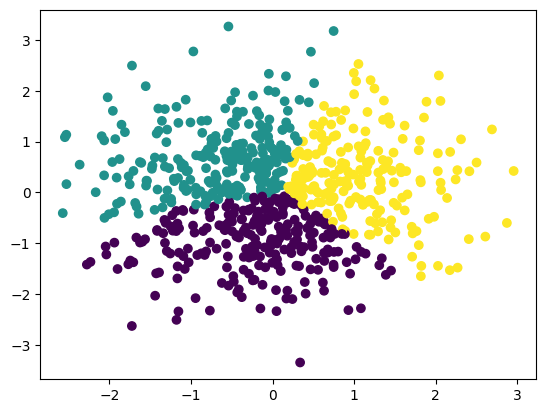

In [ ]:
plt.scatter(x_train[:,0],x_train[:,1],c=kmean.labels_)

#**NATURAL LANGUAGE PROCESSING**

# TOKENIZATION

In [ ]:
import nltk
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize
text = "I love learning Natural Language Processing."

tokens = word_tokenize(text)
print(tokens)

['I', 'love', 'learning', 'Natural', 'Language', 'Processing', '.']


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# STOP WORD RENMOVAL

In [ ]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

text = "I am learning Natural Language Processing."
words = word_tokenize(text)
stop_words = set(stopwords.words("english"))
filtered_words = []

for word in words:
    if word.lower() not in stop_words:
        filtered_words.append(word)

print(filtered_words)

['learning', 'Natural', 'Language', 'Processing', '.']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# STEMMING

In [ ]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
words = ["playing", "walking", "studies", "running"]

for word in words:
    print(word, "->", stemmer.stem(word))

playing -> play
walking -> walk
studies -> studi
running -> run


# LEMMATIZATION

In [ ]:
import nltk
nltk.download('wordnet')

from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
words = ["studies", "good"]

for word in words:
    print(word, "->", lemmatizer.lemmatize(word))

studies -> study
good -> good


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')



text = "I love learning Natural Language Processing Studies."

tokens = word_tokenize(text)
stop_words = set(stopwords.words("english"))

print(tokens)
print(filtered_words)

filtered_words = []
lemmatizer = WordNetLemmatizer()


for word in tokens:
    if word.lower() not in stop_words:
        filtered_words.append(word)

for word in filtered_words:
    print(word, "->", lemmatizer.lemmatize(word))

print(tokens)
print(filtered_words)

['I', 'love', 'learning', 'Natural', 'Language', 'Processing', 'Studies', '.']
['love', 'learning', 'Natural', 'Language', 'Processing', 'Studies', '.']
love -> love
learning -> learning
Natural -> Natural
Language -> Language
Processing -> Processing
Studies -> Studies
. -> .
['I', 'love', 'learning', 'Natural', 'Language', 'Processing', 'Studies', '.']
['love', 'learning', 'Natural', 'Language', 'Processing', 'Studies', '.']


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
